# Cartographier l'influence déclarée des lobbies sur le travail législatif

**Python pour la data science — ENSAE 2A, `CSC_4CS08_AE`**

---

Trois sources officielles, une question : *la présence déclarée de lobbies sur un texte
de loi laisse-t-elle une trace observable dans le travail et les votes des députés ?*

- **qui déclare cibler quoi** → répertoire des représentants d'intérêts de la HATVP ;
- **qui écrit quoi** → amendements de l'Assemblée nationale ;
- **qui vote quoi** → scrutins publics nominatifs.

L'objectif n'est pas de prouver une corruption — ce serait indéfendable avec ces données.
Il est de **cartographier une influence déclarée** et de mesurer honnêtement ce qu'on peut
en conclure.

> **Comment lire ce notebook.** Il ne télécharge rien et ne recalcule rien : il relit les
> tables produites par `make pipeline` et s'exécute en moins d'une minute. Toute la logique
> est dans `src/lobbynomics/` ; ici, on commente.

**Plan.** 1. Les données et leur qualité — 2. Rapprocher les bases (le cœur du travail) —
3. L'écosystème autour de chaque texte — 4. Les votes — 5. Construire une mesure
d'exposition — 6. Modélisation — 7. Robustesse — 8. Conclusion.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd

from lobbynomics import config, features, matching, models, quality, robustesse, viz

viz.style()
pd.set_option("display.max_columns", 40, "display.width", 150, "display.max_colwidth", 70)


def charger(nom: str) -> pd.DataFrame:
    """Relit une table produite par le pipeline, avec un message clair si elle manque."""
    chemin = config.PROCESSED / f"{nom}.parquet"
    if not chemin.exists():
        raise FileNotFoundError(
            f"{chemin.name} absent — lancez d'abord : make pipeline")
    return pd.read_parquet(chemin)


print("tables disponibles :", len(list(config.PROCESSED.glob("*.parquet"))))

tables disponibles : 26


## 1. Les données

### 1.1 Ce qui a été collecté

Huit fichiers, quatre producteurs, environ 700 Mo. Aucune authentification : tout est
retéléchargeable par `make donnees`.

In [2]:
import json

manifeste = json.loads((config.RAW / "_manifeste.json").read_text(encoding="utf-8"))
inventaire = (pd.DataFrame(manifeste).T
              .assign(taille_Mo=lambda d: (d["octets"] / 1e6).round(1))
              .loc[:, ["description", "taille_Mo", "recupere_le"]])
inventaire

,description,taille_Mo,recupere_le
hatvp_repertoire,Répertoire des représentants d'intérêts : fiches + activités décla...,138.501819,2026-10-02T16:43:23+00:00
hatvp_liste,"Index des déclarations des responsables publics (DI, DIA, DSP).",3.18828,2026-10-02T16:43:23+00:00
hatvp_declarations,Contenu des déclarations d'intérêts et d'activités.,79.520455,2026-10-02T16:43:23+00:00
an_scrutins,"Scrutins publics de la XVIIe législature, vote nominatif par député.",26.378308,2026-10-02T16:43:23+00:00
an_amendements,"Amendements déposés en commission et en séance, auteur et sort.",303.824365,2026-10-02T16:43:23+00:00
an_dossiers,"Dossiers législatifs : titres, étapes, textes associés.",10.519747,2026-10-02T16:43:23+00:00
an_acteurs,"Acteurs, mandats et organes : identité des députés, groupes, commi...",13.61893,2026-10-02T16:43:23+00:00
geo_communes,"API Géo (Etalab) : population et surface de chaque commune, pour c...",4.146354,2026-10-02T16:43:23+00:00


Le manifeste n'est pas décoratif : il enregistre pour chaque fichier son URL, sa taille et
une empreinte SHA-256. C'est ce qui permet de dire **quelle version des données** a produit
les résultats ci-dessous — une source open data change sans prévenir.

### 1.2 Volumes après mise à plat

In [3]:
tables = {nom: charger(nom) for nom in [
    "an_deputes", "an_dossiers", "an_scrutins", "an_votes", "an_amendements", "an_deports",
    "hatvp_organisations", "hatvp_activites", "hatvp_interets_deputes", "geo_departements",
]}
volumes = pd.DataFrame(
    [{"table": nom, "lignes": len(df), "colonnes": df.shape[1]} for nom, df in tables.items()]
).sort_values("lignes", ascending=False).reset_index(drop=True)
volumes

,table,lignes,colonnes
0,an_votes,1273091,6
1,an_amendements,126392,18
2,hatvp_activites,113075,22
3,hatvp_interets_deputes,11438,15
4,an_scrutins,8455,13
5,hatvp_organisations,4094,18
6,an_dossiers,2971,9
7,an_deputes,649,24
8,geo_departements,109,9
9,an_deports,59,11


1,27 million de votes nominatifs et 126 392 amendements d'un côté, 113 075 activités de
lobbying déclarées de l'autre. Le volume n'est pas le problème de ce projet.

### 1.3 Le vrai problème : aucune clé commune

Un coup d'œil à ce que contient réellement une activité du répertoire HATVP suffit à le voir.

In [4]:
activites = tables["hatvp_activites"]
exemple = activites.loc[activites["objet"].str.len().between(80, 160), [
    "denomination", "exercice_annee", "domaines", "objet", "decisions_concernees"]].head(3)
for _, ligne in exemple.iterrows():
    print(f"{ligne['denomination']}  —  exercice {ligne['exercice_annee']}")
    print(f"  objet     : {ligne['objet']}")
    print(f"  domaines  : {ligne['domaines']}")
    print(f"  décisions : {ligne['decisions_concernees']}\n")

CONFEDERATION DES PETITES ET MOYENNES ENTREPRISES DE CREUSE (CPME23 OU CPME CREUSE)  —  exercice 2023
  objet     : Limiter le champ de la décision de la cour de cassation sur les congés payés acquis durant les arrêts maladie
  domaines  : Entreprises et professions libérales
  décisions : Lois, y compris constitutionnelles

FEDERAT NAT CTRE LUTTE CONTRE LE CANCER  —  exercice 2025
  objet     : Echanger sur la situation des Centres de lutte contre le cancer et du secteur privé non lucratif en amont du PLFSS
  domaines  : Santé
  décisions : Autres décisions publiques

FEDERAT NAT CTRE LUTTE CONTRE LE CANCER  —  exercice 2025
  objet     : PLFSS : Demander la préservation de l’accès aux traitements onéreux dans le cadre de la réforme de la liste en
sus et le renforcement du cadre de concertation
  domaines  : Santé
  décisions : Lois, y compris constitutionnelles



Ni numéro de texte, ni date précise : un objet en texte libre et une année d'exercice.
Relier ça à un dossier législatif est une **inférence**, pas une jointure.

In [5]:
print(f"activités déclarées                : {len(activites):>7,}".replace(",", " "))
print(f"dont visant le Parlement           : {activites['cible_parlement'].sum():>7,}".replace(",", " "))
print(f"dont portant sur des « Lois »      : {activites['cible_loi'].sum():>7,}".replace(",", " "))
print(f"organisations déclarantes          : {activites['identifiant_national'].nunique():>7,}".replace(",", " "))

activités déclarées                : 113 075
dont visant le Parlement           :  70 630
dont portant sur des « Lois »      :  64 408
organisations déclarantes          :   3 365


### 1.4 Contrôles de qualité

Une erreur de parsing produit une exception, qu'on voit. Une erreur de données produit un
tableau plausible et faux, qu'on ne voit pas. Le module `quality` écrit noir sur blanc ce
qu'on attend des tables et vérifie que c'est vrai.

In [6]:
controles = quality.controler_tout(charger)
controles["statut"].value_counts().rename("nombre de contrôles").to_frame()

,nombre de contrôles
statut,
ok,24


In [7]:
controles.head(12)

,contrôle,portée,constat,statut,commentaire
0,unicité de amendement_uid,an_amendements,126 392 lignes 0 doublon(s) 0 valeur(s) manquante(s),ok,
1,sort renseigné si et seulement si l'amendement a été discuté,an_amendements,70 185 discutés 70 185 avec sort 0 incohérence(s),ok,les 44 % sans sort sont des amendements non discutés (irrecevables...
2,auteur individuel absent si et seulement si l'amendement est gouve...,an_amendements,1 442 amendements du Gouvernement 0 incohérence(s) 4 amendement(...,ok,un amendement du Gouvernement n'a pas d'auteur député : c'est normal
3,plage de date_depot,an_amendements,"2024-09-18 → 2026-10-02, 0 hors fenêtre [2024-07-01 ; 2029-12-31]",ok,
4,complétude de texte_ref,an_amendements,0.0 % manquants,ok,
5,complétude de etat,an_amendements,0.0 % manquants,ok,
6,unicité de acteur_ref,an_deputes,649 lignes 0 doublon(s) 0 valeur(s) manquante(s),ok,
7,complétude de acteur_ref,an_deputes,0.0 % manquants,ok,
8,complétude de nom_complet,an_deputes,0.0 % manquants,ok,
9,complétude de groupe_abrev,an_deputes,0.0 % manquants,ok,


Trois anomalies apparentes ont été remontées par une première version de ces contrôles.
Toutes les trois se sont révélées être des **régularités explicables**, et c'est pour ça
qu'elles sont devenues des contrôles précis plutôt que des seuils génériques :

| Anomalie apparente | Explication trouvée |
| --- | --- |
| 44,5 % des amendements sans `sort` | un amendement n'a de sort que s'il a été *discuté* : la relation est exacte, pas approximative |
| 1,1 % des amendements sans auteur | ce sont exactement les amendements du **Gouvernement**, qui n'a pas d'auteur député |
| 12 scrutins pointant vers un dossier introuvable | leurs identifiants commencent tous par `DLR5L16` : textes entamés sous la **XVIe** législature |

Quatre lignes résistaient encore à la deuxième explication : des amendements à l'état
« effacé », dont l'auteur a été retiré en même temps que le contenu. Quatre lignes sur
126 392 — mais quatre lignes inexpliquées suffisent à faire douter du reste.

## 2. Rapprocher les bases — le cœur du travail

### 2.1 Rattacher un scrutin à son dossier

Sur 8 455 scrutins, **5 826 n'ont aucun lien explicite** vers leur dossier législatif. Mais
leur titre nomme le texte.

In [8]:
exemples = [
    "l'amendement n° 190 de M. Golliot après l'article 2 de la proposition de loi visant "
    "à la nationalisation d'ArcelorMittal France (première lecture).",
    "l'ensemble du projet de loi d'urgence pour la protection et la souveraineté "
    "agricoles (nouvelle lecture).",
    "l'ensemble du texte.",
]
for titre in exemples:
    print(f"{titre[:78]:<80} → {matching.extraire_denomination(titre)!r}")

l'amendement n° 190 de M. Golliot après l'article 2 de la proposition de loi v   → 'visant a la nationalisation d arcelormittal france'
l'ensemble du projet de loi d'urgence pour la protection et la souveraineté ag   → 'd urgence pour la protection et la souverainete agricoles'
l'ensemble du texte.                                                             → ''


Le dernier cas montre la limite : certains titres ne nomment aucun texte et resteront non
rattachés.

### 2.2 Mesurer le taux d'erreur — gratuitement

Les 2 608 scrutins qui portent **déjà** un lien explicite et dont le titre est exploitable
forment une vérité terrain. On leur applique quand même la méthode floue, et on compare.

In [9]:
qualite_matching = charger("audit_rattachement_scrutins")
qualite_matching.assign(couverture=lambda d: (100 * d["couverture"]).round(1),
                        precision=lambda d: (100 * d["precision"]).round(1))

,seuil,n_test,n_retenus,couverture,precision
0,60,2608,2608,100.0,83.9
1,65,2608,2583,99.0,84.7
2,70,2608,2561,98.2,84.6
3,75,2608,2558,98.1,84.6
4,80,2608,2175,83.4,99.5
5,85,2608,2164,83.0,99.5
6,90,2608,2149,82.4,99.5
7,95,2608,2143,82.2,99.5
8,100,2608,2118,81.2,99.5


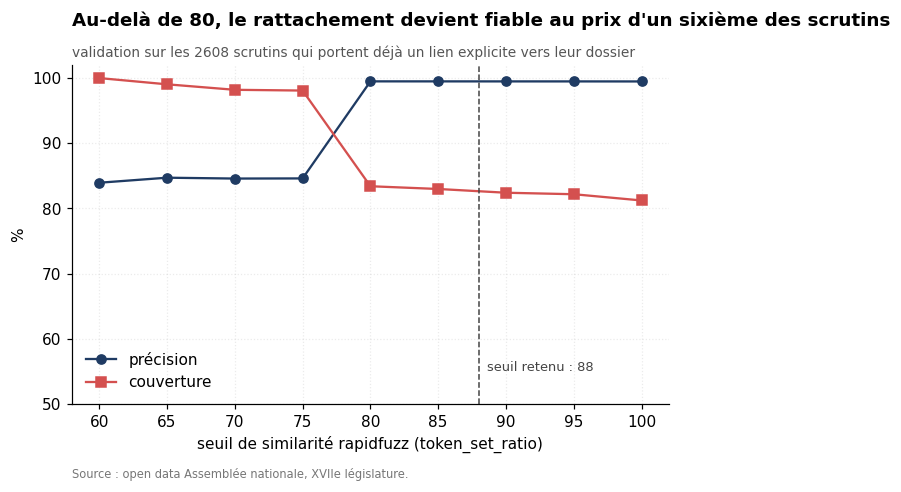

In [10]:
figure = viz.figure_qualite_matching(qualite_matching)

**Lecture.** La marche entre les seuils 75 et 80 est franche : en dessous, on rattache des
textes seulement voisins. Au-delà, la précision plafonne à **99,5 %** pour une couverture de
83 %. Le seuil retenu (88) est pris au milieu du plateau.

**Comment on est passé de 95,7 % à 99,5 %.** La première version s'arrêtait à la similarité
de titre. En relisant les erreurs, le motif saute aux yeux : l'Assemblée ouvre un dossier
distinct par lecture, et plusieurs dossiers portent *exactement* le même titre
(« Nationalisation d'ArcelorMittal France » existe deux fois). Un score de 100 ne départage
alors rien. L'arbitrage par la date du scrutin règle le problème.

In [11]:
scrutins = charger("scrutins_rattaches")
repartition = scrutins["origine_lien"].value_counts()
print(repartition.to_string())
print(f"\ntaux de rattachement global : "
      f"{100 * (1 - repartition.get('aucun', 0) / len(scrutins)):.1f} %")
print(f"scrutins dont la dénomination correspond à plusieurs dossiers homonymes : "
      f"{(scrutins['n_candidats_ex_aequo'] > 1).sum():,}".replace(",", " "))

origine_lien
fuzzy      5041
declare    2629
aucun       785

taux de rattachement global : 90.7 %
scrutins dont la dénomination correspond à plusieurs dossiers homonymes : 3 523


### 2.3 Rattacher une activité HATVP à un texte de loi

Là, aucune vérité terrain n'existe. Il faut relire à la main.

**Première tentative.** Secteur compatible, domaine compatible, mot-clé du texte présent,
exercice recouvrant la fenêtre de débat → 904 activités retenues pour la loi agricole. Un
échantillon relu une à une donne une précision d'environ **16 %**. Les faux positifs
viennent de mots-clés trop généraux attrapés hors contexte (« filière », « haie »).

**Deuxième tentative, retenue.** Deux niveaux explicites :

| Niveau | Règle | Usage |
| --- | --- | --- |
| 1 | l'objet déclaré **nomme** le texte (intitulé officiel ou alias d'usage, en sous-chaîne exacte) | variable d'analyse |
| 2 | voisinage thématique (l'ancienne règle) | description de l'écosystème, jamais preuve |

In [12]:
ciblage = charger("ciblage_hatvp")
bilan = (ciblage.groupby("texte_cle")
         .agg(paires_eligibles=("eligible", "sum"),
              niveau_1=("cible_nommee", "sum"),
              niveau_2=("cible_thematique", "sum"))
         .reindex([t.cle for t in config.TEXTES_CIBLES]))
bilan["organisations_niveau_1"] = (
    ciblage[ciblage["cible_nommee"]].groupby("texte_cle")["identifiant_national"]
    .nunique().reindex(bilan.index).fillna(0).astype(int))
bilan

,paires_eligibles,niveau_1,niveau_2,organisations_niveau_1
texte_cle,,,,
agriculture,11501,29,904,18
defense,11502,14,44,11
fraudes,11948,165,16,53
logement,11501,0,419,0


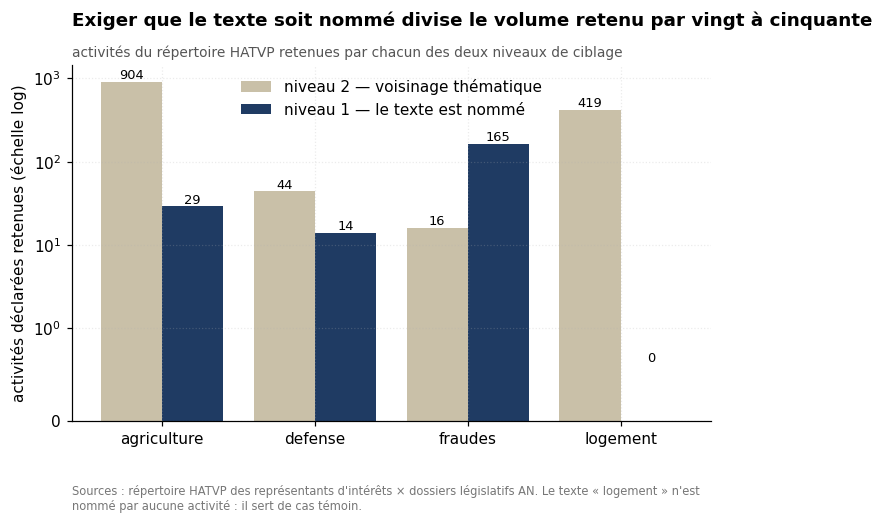

In [13]:
figure = viz.figure_intensite_lobbying(ciblage)

**Le cas témoin.** Le texte `logement` est thématiquement proche de 419 activités, et nommé
par **zéro**. Si le voisinage thématique mesurait le ciblage, ce chiffre serait impossible.
C'est la démonstration la plus économique que « proximité de thème » n'est pas « ciblage »,
et la raison pour laquelle `logement` est exclu de la modélisation.

### 2.4 Pourquoi aucune similarité floue au niveau 1

Une version intermédiaire utilisait `partial_token_set_ratio` entre le titre du texte et
l'objet déclaré. Elle retenait 11 170 activités sur 11 501, dont des déclarations sur le
PLFSS pour la loi agricole.

In [14]:
from rapidfuzz import fuzz

from lobbynomics.parse_an import normaliser

texte = config.TEXTES_PAR_CLE["defense"]
hors_sujet = normaliser("PLFSS : demander la préservation de l'accès aux traitements onéreux")
print(f"partial_token_set_ratio(titre LPM, objet PLFSS) = "
      f"{fuzz.partial_token_set_ratio(normaliser(texte.libelle), hors_sujet):.0f}  ← inutilisable")
print(f"règle retenue (le texte est-il nommé ?)         = "
      f"{matching.nomme_le_texte(hors_sujet, texte)}")
print(f"  et sur un objet qui nomme vraiment la LPM     = "
      f"{matching.nomme_le_texte(normaliser('LPM 2024-2030 : défendre la sanctuarisation'), texte)}")

partial_token_set_ratio(titre LPM, objet PLFSS) = 100  ← inutilisable
règle retenue (le texte est-il nommé ?)         = False
  et sur un objet qui nomme vraiment la LPM     = True


Le flou est le bon outil pour comparer **deux titres** (section 2.1). Il est le mauvais
outil pour chercher un titre **dans un paragraphe**. Le même piège s'est reproduit plus tard
sur les déports (section 2.7) : il y est documenté et testé.

### 2.5 L'audit manuel

60 paires tirées au sort, 20 par niveau, relues une à une. Les cas plausibles mais
invérifiables sont annotés `incertain` et **exclus** du calcul : les ranger d'un côté ou de
l'autre fabriquerait le résultat.

In [15]:
audit = pd.read_csv(config.PROCESSED / "audit_ciblage_a_annoter.csv")
matching.precision_par_niveau(audit)

,n_annote,n_vrais,n_incertains,precision
niveau_ciblage,,,,
0 - écarté,20,0,0,0.000
1 - texte nommé,20,20,0,1.000
2 - voisinage thématique,20,1,4,0.062


In [16]:
mesures = matching.taux_erreur(audit, colonne="cible_nommee")
print(f"précision du niveau 1 : {100 * mesures['precision']:.0f} %  "
      f"({mesures['vp']} vrais positifs, {mesures['fp']} faux positifs)")
print(f"rappel sur l'échantillon : {100 * mesures['rappel']:.0f} %  "
      f"({mesures['fn']} activité ciblante manquée)")
print(f"paires jugées incertaines, exclues du calcul : {mesures['n_incertain']}")

précision du niveau 1 : 100 %  (20 vrais positifs, 0 faux positifs)
rappel sur l'échantillon : 95 %  (1 activité ciblante manquée)
paires jugées incertaines, exclues du calcul : 4


In [17]:
# Les deux faux positifs du niveau 2 qu'on aurait pris pour des ciblages avérés.
colonnes = ["texte_cle", "denomination", "objet", "verdict_manuel", "commentaire"]
audit.loc[audit["niveau_ciblage"].str.startswith("2") & audit["verdict_manuel"].eq("non"),
          colonnes].head(4)

,texte_cle,denomination,objet,verdict_manuel,commentaire
5,agriculture,OMNICOM PUBLIC RELATIONS GROUP,Inviter des décideurs publics à un petit-déjeuner pour valoriser l...,non,"valorisation de filière, hors texte"
7,logement,PLEAD,supprimer l'interdiction de refacturation de la taxe foncière aux ...,non,"PJL simplification de la vie économique, autre véhicule"
18,agriculture,UITS,PLF 2026 : soutenir la compétitivité de la filière des traitements...,non,PLF 2026
22,agriculture,ASS NATIONALE IND. AGRO ALIMENTAIRES,PLF 2026 : Tarif réduit pour les entreprises de l'agroalimentaire ...,non,PLF 2026


L'unique faux négatif écrivait « PJL Agricole », forme absente de la liste d'alias
initiale. L'alias a été ajouté, ce qui a capturé trois activités supplémentaires, toutes
vérifiées et correctes. Cette itération est documentée plutôt que masquée : le seuil n'a pas
été réglé sur le résultat final, une erreur identifiée a été corrigée.

**Attention à la lecture** : l'échantillon est stratifié, pas aléatoire simple. Ces
précisions valent *par strate* et ne s'extrapolent pas en taux global.

### 2.6 Un contre-exemple : quand la source fournit la clé

In [18]:
deputes = charger("deputes_hatvp")
print(f"députés appariés à leur fiche HATVP par le champ `uri_hatvp` (clé exacte) : "
      f"{100 * deputes['nb_declarations'].notna().mean():.0f} %")
print(f"appariés au contenu des déclarations par nom normalisé (approximatif)    : "
      f"{100 * deputes['nb_interets'].gt(0).mean():.0f} %")
deputes.loc[deputes["uri_hatvp"].notna(),
            ["nom_complet", "groupe_abrev", "departement", "uri_hatvp"]].head(3)

députés appariés à leur fiche HATVP par le champ `uri_hatvp` (clé exacte) : 88 %
appariés au contenu des déclarations par nom normalisé (approximatif)    : 78 %


,nom_complet,groupe_abrev,departement,uri_hatvp
0,Alain David,SOC,Gironde,https://www.hatvp.fr/pages_nominatives/david-alain
2,Jérôme Guedj,SOC,Essonne,https://www.hatvp.fr/pages_nominatives/guedj-jerome
3,David Habib,LIOT,Pyrénées-Atlantiques,https://www.hatvp.fr/pages_nominatives/habib-david


L'open data de l'Assemblée publie l'URL de la fiche HATVP de chaque député. Aucun fuzzy
matching n'est nécessaire. La leçon, qui vaut au-delà de ce projet : **chercher la clé
fournie par la source avant d'inventer la sienne.**

### 2.7 Les déports : le seul lien nommé entre un député, un intérêt et un texte

Un « déport » est la décision d'un député de ne pas prendre part à un vote en raison d'un
intérêt personnel. C'est, dans tout le paysage de données exploré ici, **le seul endroit où
un député, un intérêt privé et un texte précis sont nommés ensemble** — le répertoire HATVP
ne nomme jamais le député approché, les déclarations d'intérêts ne nomment aucun texte.

Mais il y en a 59 depuis 2017, dont 9 pour la législature en cours. Aucune statistique n'est
possible : c'est une source qualitative, et un **point de vérification** du reste de la
chaîne, puisque les scrutins étant nominatifs, un déport annoncé est contrôlable.

In [19]:
deports = charger("analyse_deports")
colonnes = ["nom_complet", "groupe_abrev", "type_cible", "titre_dossier",
            "n_scrutins_dossier", "n_votes_exprimes", "verifiable"]
deports[colonnes]

,nom_complet,groupe_abrev,type_cible,titre_dossier,n_scrutins_dossier,n_votes_exprimes,verifiable
0,Joséphine Missoffe,EPR,Article(s),Fin de vie,380,93,False
1,Joséphine Missoffe,EPR,Article(s),Projet de loi de financement de la sécurité sociale pour 2026,524,288,False
2,Joséphine Missoffe,EPR,Article(s),Projet de loi de financement de la sécurité sociale pour 2026,524,288,False
3,Jean-Didier Berger,DR,Article(s),Projet de loi de finances pour 2025,0,0,False
4,Astrid Panosyan-Bouvet,EPR,Amendement(s),None,0,0,False
5,Joséphine Missoffe,EPR,Article(s),None,0,0,False
6,Denis Masséglia,EPR,"Projet ou proposition de loi ou de résolution, dans son intégralité",Projet de loi actualisant la programmation militaire pour les anné...,292,1,True
7,Karl Olive,EPR,Article(s),"Proposition de loi relative à l'organisation, à la gestion et au f...",76,0,False
8,Henri Alfandari,HOR,Article(s),Projet de loi de financement de la sécurité sociale pour 2026,524,8,False


Deux limites immédiates se lisent dans ce tableau, et elles sont instructives :

* la plupart des déports visent **certains articles**, pas le texte entier ; on ne peut donc
  pas conclure au niveau du dossier, puisque le député a le droit de voter sur tout le reste ;
* deux références (« Articles de loi ayant trait aux assurances… ») ne nomment aucun texte
  identifiable, et restent volontairement non rattachées.

Un seul déport est vérifiable au niveau du dossier.

In [20]:
verifiable = deports[deports["verifiable"]]
for _, ligne in verifiable.iterrows():
    print(f"{ligne['nom_complet']} ({ligne['groupe_abrev']}) — déport publié le "
          f"{ligne['date_publication']}")
    print(f"  portée      : {ligne['portee']}")
    print(f"  motif       : {ligne['explication']}")
    print(f"  texte visé  : {ligne['titre_dossier']}")
    print(f"  scrutins du dossier postérieurs au déport : {ligne['n_scrutins_dossier']}")
    print(f"  dont votes exprimés par ce député         : {ligne['n_votes_exprimes']}")

Denis Masséglia (EPR) — déport publié le 2026-04-13
  portée      : Être absent pour la totalité du processus législatif concerné
  motif       : Je suis actuellement en disponibilité de l'entreprise THALES.
  texte visé  : Projet de loi actualisant la programmation militaire pour les années 2024 à 2030 et portant diverses dispositions intéressant la défense
  scrutins du dossier postérieurs au déport : 292
  dont votes exprimés par ce député         : 1


**Lecture, et rien de plus.** Sur les 292 scrutins du dossier postérieurs au déport, le
député n'apparaît dans le détail nominatif que pour **un seul vote** — le vote sur
l'ensemble du texte issu de la commission mixte paritaire. Les données disent cela, et
s'arrêtent là : elles ne disent pas si c'est un oubli, un changement de situation, ou une
lecture du déport qui en exclut le vote final. Ce qu'il faut retenir pour le projet, c'est
qu'un engagement public **peut** être vérifié ligne à ligne dès lors que la source nomme à
la fois la personne et le texte — ce qui est précisément ce qui manque au répertoire HATVP.

## 3. Qui gravite autour de ces textes ?

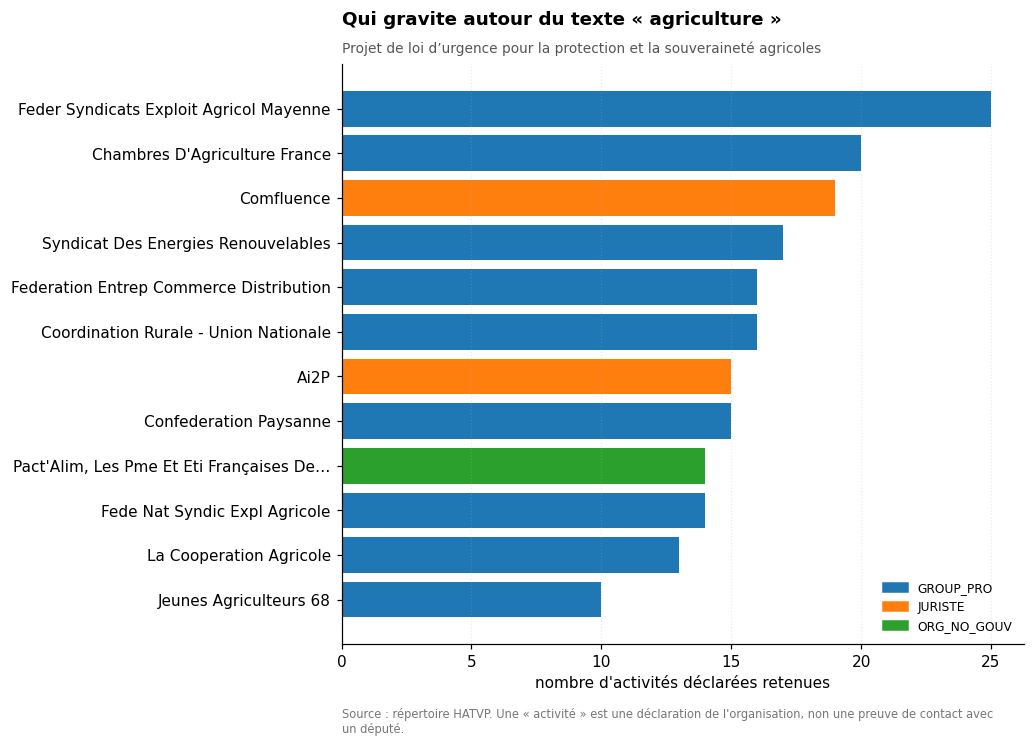

In [21]:
figure = viz.figure_top_organisations(ciblage, "agriculture")

Syndicats agricoles, chambres d'agriculture, interprofessions, mais aussi cabinets de
conseil en affaires publiques, qui déclarent pour le compte de clients.

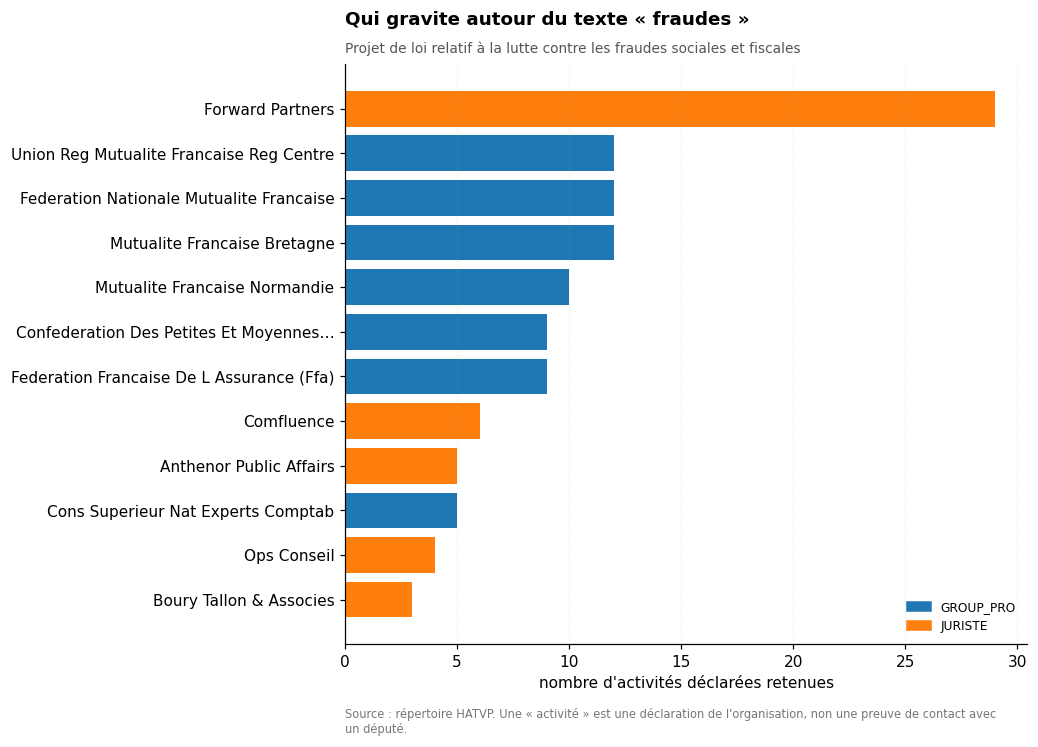

In [22]:
figure = viz.figure_top_organisations(ciblage, "fraudes")

In [23]:
fraudes = ciblage[(ciblage["texte_cle"] == "fraudes") & ciblage["cible_nommee"]]
for _, ligne in fraudes.drop_duplicates("denomination").head(6).iterrows():
    print(f"• {ligne['denomination'][:38]:<40} {str(ligne['objet'])[:105]}")

• FED DEP ENTREPRENEUR ARTISAN BATIMENT    Inscrire des limitation de sous-traitance dans le projet de loi relatif à la lutte contre les fraudes soc
• STRATEGIES & PUBLICS                     PJL Fraudes sociales et fiscales : renforcer le dispositif de lutte contre la fraude au compteur d'électr
• REGIE AUTONOME DES TRANSPORTS PARISIEN   PJL Lutte contre les fraudes sociales et fiscales : Obtenir des moyens supplémentaires de lutte contre la
• FEDERAT BATIM TRAVAUX PUBLIC REGION HA   Inscrire dans la loi relative à la lutte contre les fraudes sociales et fiscales des dispositions destiné
• FED DEP BATIMENT TRAVAUX PUBLIC CALVAD   Proposer des amendements pour encadrer la sous-traitance dans le BTP et limiter les fraudes sociales et f
• FEDERATION DES BATIMENTS ET DES TP DE    inscrire dans le projet de loi visant à lutter contre les fraudes sociales et fiscales, la limitation de 


Sur la lutte contre les fraudes, la population est tout autre : mutuelles et fédérations
professionnelles, portant des demandes parfois opposées entre elles.

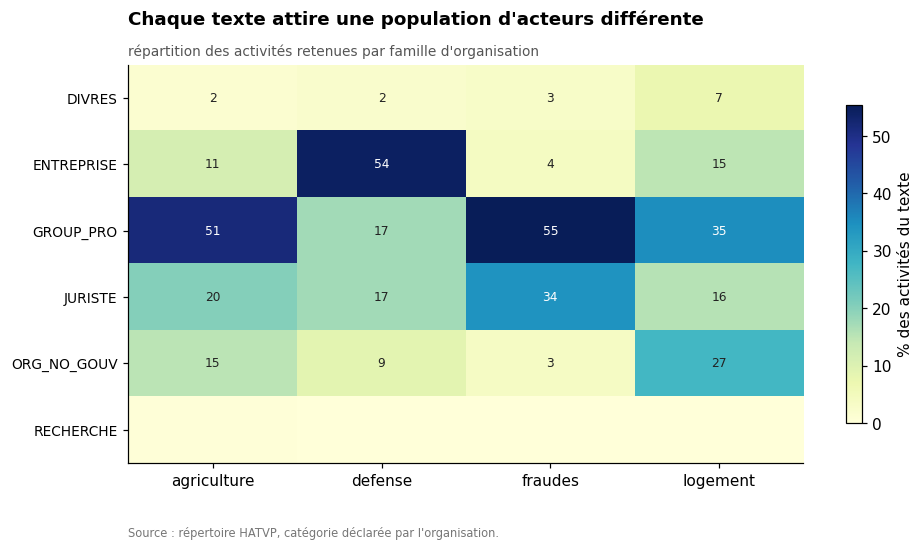

In [24]:
figure = viz.figure_secteurs_textes(ciblage)

Chaque texte attire une population d'acteurs différente. Cette figure utilise les deux
niveaux de ciblage, puisqu'elle décrit un écosystème et ne prétend à aucun rattachement
individuel.

## 4. Les votes

### 4.1 Le vote final ne contient aucune information à expliquer

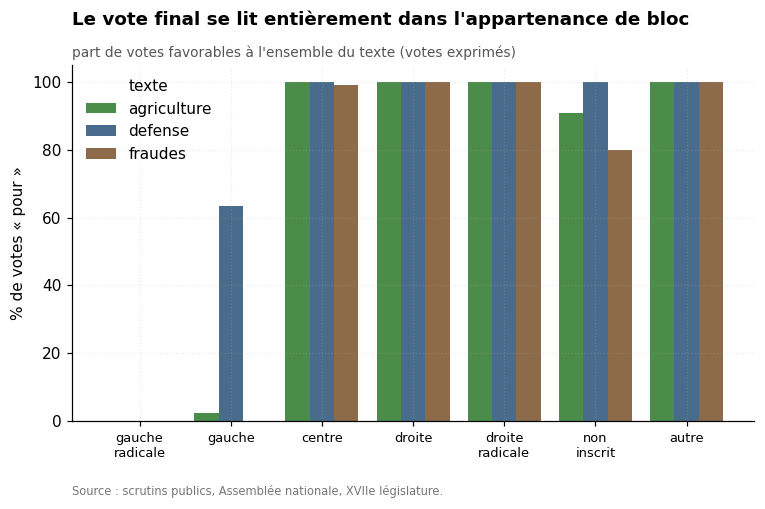

In [25]:
table_finale = charger("analyse_votes_finaux")
figure = viz.figure_votes_par_bloc(table_finale)

In [26]:
models.pouvoir_predictif_bloc(table_finale)

,n,part_pour,exactitude_regle_bloc,nb_votes_atypiques
texte_cle,,,,
agriculture,547,0.6746,0.9945,3
defense,562,0.7829,0.9342,37
fraudes,557,0.6517,0.9946,3


**Lecture.** La règle « chaque député vote comme la majorité de son bloc » se trompe sur
**3 votes sur 547** pour la loi agricole, 3 sur 557 pour les fraudes, 37 sur 562 pour la loi
de programmation militaire — ce dernier texte étant le seul à fracturer un bloc.

Conséquence directe : un logit avec effets fixes de bloc **ne peut pas converger**, parce
que cinq blocs sur sept votent à 0 % ou 100 %. Le code le détecte et le dit, au lieu
d'afficher des écarts-types astronomiques.

In [27]:
vote = models.modele_vote_final(table_finale)
print(f"observations : {vote['n']}")
print(f"part des observations dans une modalité parfaitement séparée : "
      f"{100 * vote['part_observations_separees']:.0f} %")
print(f"modèle identifiable : {vote.get('identifiable')}\n")
vote["separation"]

vote final : ajustement impossible (LinAlgError) — séparation quasi complète


observations : 1666
part des observations dans une modalité parfaitement séparée : 55 %
modèle identifiable : False



,part_cible,effectif,separe
bloc,,,
autre,1.0000,50,True
centre,0.9976,420,False
droite,1.0000,247,True
droite radicale,1.0000,361,True
gauche,0.2230,296,False
gauche radicale,0.0000,260,True
non inscrit,0.9062,32,False


### 4.2 La dissidence sur les amendements : le bon niveau d'observation

In [28]:
dissidence = charger("analyse_dissidence")
print(f"{len(dissidence):,} votes exprimés".replace(",", " "),
      f"sur {dissidence['scrutin_uid'].nunique()} scrutins d'amendements,",
      f"{dissidence['acteur_ref'].nunique()} députés")
print(f"taux de dissidence global : {100 * dissidence['dissident'].mean():.2f} %")
print(f"députés ayant dissidé au moins une fois : "
      f"{100 * dissidence.groupby('acteur_ref')['dissident'].max().mean():.0f} %")

89 472 votes exprimés sur 970 scrutins d'amendements, 554 députés
taux de dissidence global : 4.31 %
députés ayant dissidé au moins une fois : 83 %


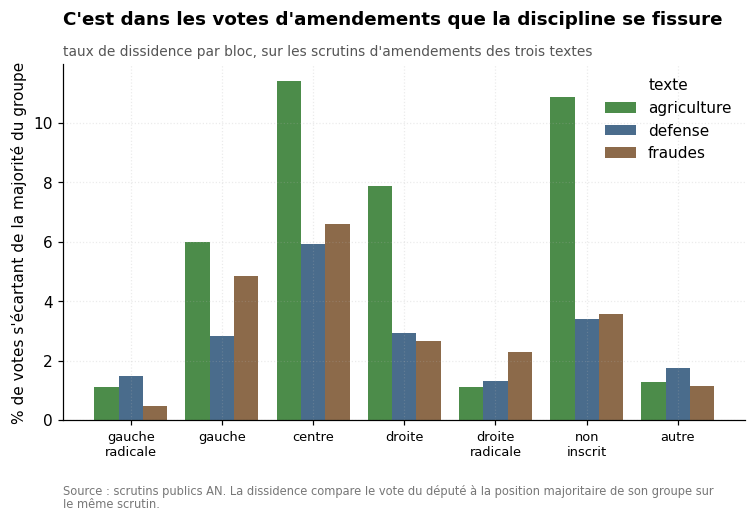

In [29]:
figure = viz.figure_dissidence(dissidence)

Les blocs de gouvernement et les non-inscrits s'écartent nettement plus souvent de leur
groupe que les blocs les plus structurés. C'est cette variation — 4,3 % des votes — qui rend
une régression possible.

## 5. L'exposition au lobbying : une variable qu'il faut construire

Le répertoire HATVP dit « j'ai contacté des députés ». Il ne dit **jamais** lequel. Une
exposition individuelle ne peut donc pas être lue dans les données ; elle doit être
construite.

**Méthode.** Un espace TF-IDF commun est appris sur l'union de deux corpus — les textes
d'amendements et les objets déclarés des lobbies de niveau 1 — puis on calcule les cosinus.
Démonstration sur un cas fabriqué, où l'on sait quelle réponse attendre :

In [30]:
amendements_test = pd.DataFrame([
    {"amendement_uid": "A1", "type_auteur": "Député", "acteur_ref": "Députée A", "adopte": True,
     "expose": "Sanctuariser la trajectoire budgétaire de la programmation militaire et "
               "garantir les commandes d'armement terrestre. " * 4, "dispositif": ""},
    {"amendement_uid": "A2", "type_auteur": "Député", "acteur_ref": "Député B", "adopte": False,
     "expose": "Protéger les haies bocagères et encadrer l'usage des produits "
               "phytosanitaires en zone de captage. " * 4, "dispositif": ""},
])
lobbies_test = pd.DataFrame([
    {"cible_texte": True, "activite_id": "L1", "denomination": "INDUSTRIE DE DÉFENSE",
     "objet": "Défendre la sanctuarisation de la trajectoire de la programmation militaire "
              "et obtenir des commandes d'armement terrestre"},
    {"cible_texte": True, "activite_id": "L2", "denomination": "ASSOCIATION BOCAGE",
     "objet": "Protéger les haies bocagères et restreindre les produits phytosanitaires "
              "dans les zones de captage"},
])
features.proximite_lobbies(amendements_test, lobbies_test, min_caracteres=50)[
    ["acteur_ref", "proximite_max", "lobby_le_plus_proche"]]

,acteur_ref,proximite_max,lobby_le_plus_proche
0,Député B,1.0,ASSOCIATION BOCAGE
1,Députée A,1.0,INDUSTRIE DE DÉFENSE


Chacun retrouve son homologue lexical.

### 5.1 Le test placebo

Rien ne garantit pour autant que la mesure capte du **sectoriel** plutôt que du **style**.
On calcule donc, pour chaque amendement, une seconde proximité : celle aux demandes
déclarées des lobbies d'un **autre** texte de l'étude. Les deux corpus sont ramenés à la
même taille, parce que le maximum d'une similarité sur N documents croît mécaniquement
avec N.

In [31]:
amendements = charger("analyse_amendements")
amendements.groupby("texte_cle").agg(
    amendements=("amendement_uid", "size"),
    texte_temoin=("texte_placebo", "first"),
    proximite_reelle=("proximite_lobby", "mean"),
    proximite_temoin=("proximite_placebo", "mean"),
).round(4)

,amendements,texte_temoin,proximite_reelle,proximite_temoin
texte_cle,,,,
agriculture,1455,defense,0.0372,0.0165
defense,483,fraudes,0.0392,0.0289
fraudes,514,agriculture,0.0656,0.0346


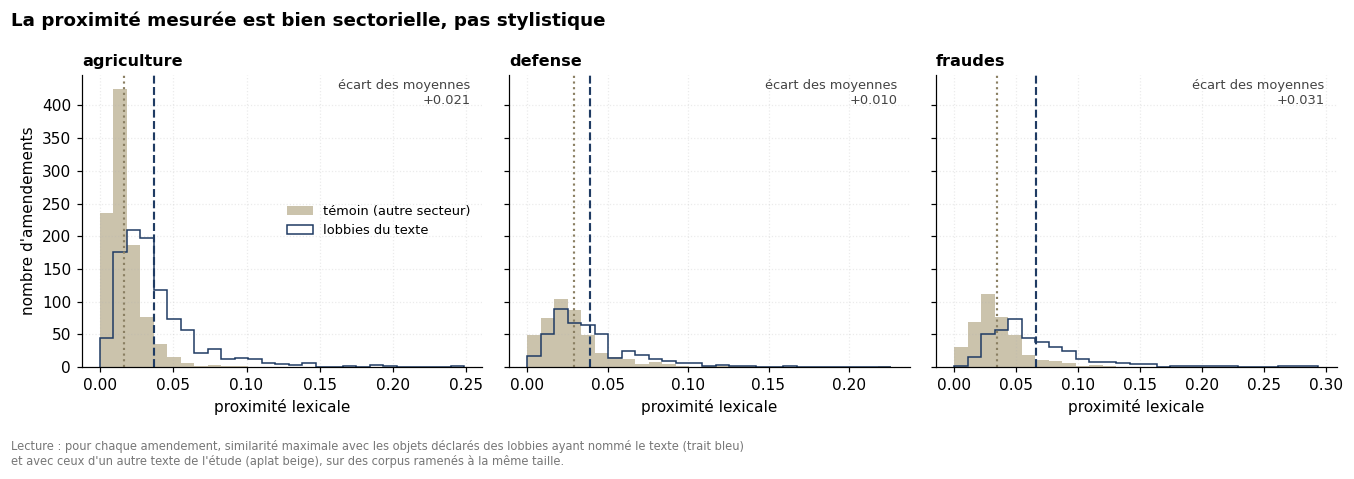

In [32]:
figure = viz.figure_placebo(amendements)

La proximité réelle domine la proximité témoin sur les trois textes. La mesure capte bien
quelque chose de sectoriel — ce qui ne dit toujours rien d'une influence, seulement que le
vocabulaire d'un amendement agricole ressemble davantage aux demandes des lobbies agricoles
qu'à celles des lobbies de la défense. C'est le minimum qu'on pouvait exiger d'elle.

### 5.2 Le graphe biparti

Chaque arête relie une organisation à un député dont les amendements emploient un
vocabulaire proche de l'objet qu'elle a déclaré. **Elle ne signifie pas qu'un contact a eu
lieu.**

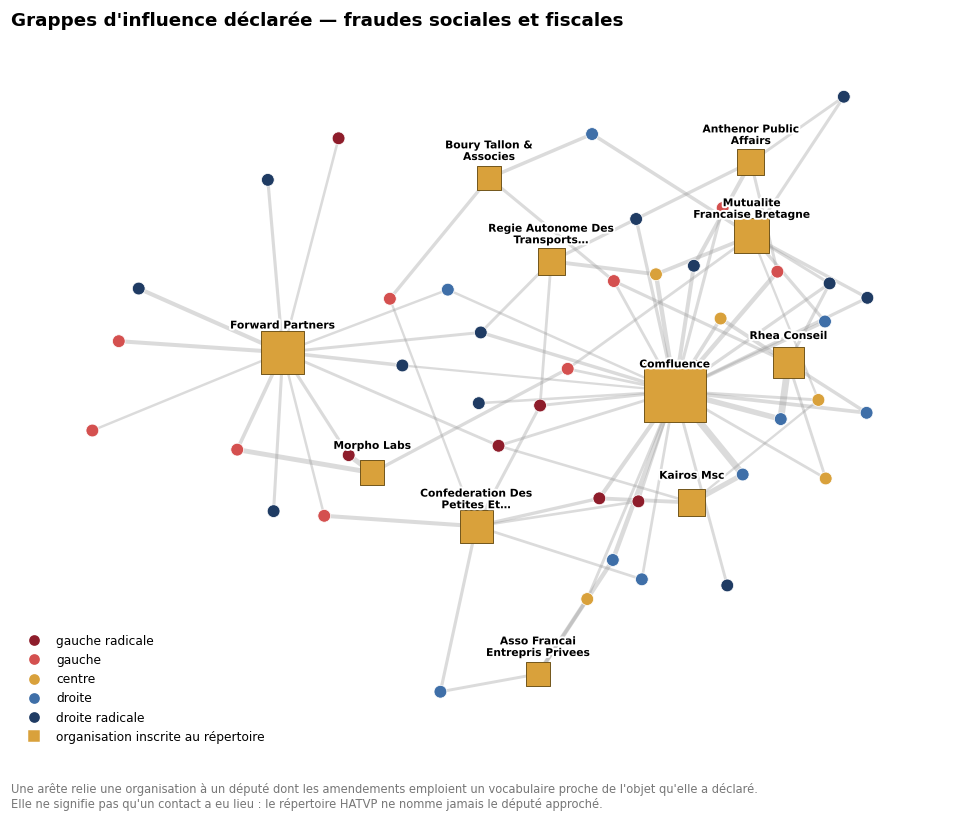

In [33]:
aretes = charger("graphe_aretes")
figure, graphe = viz.figure_graphe_biparti(
    aretes[aretes["texte_cle"] == "fraudes"], deputes, titre_texte="fraudes sociales et fiscales")

In [34]:
viz.metriques_graphe(graphe).head(8)

,noeud,type,degre,centralite_degre,centralite_intermediarite
0,🏛 Comfluence,organisation,28,0.549020,0.694118
1,🏛 Forward Partners,organisation,13,0.254902,0.312157
2,🏛 Mutualite\nFrancaise Bretagne,organisation,8,0.156863,0.097255
3,🏛 Confederation Des\nPetites Et…,organisation,7,0.137255,0.086275
4,🏛 Rhea Conseil,organisation,6,0.117647,0.002353
5,🏛 Anthenor Public\nAffairs,organisation,4,0.078431,0.007843
6,🏛 Kairos Msc,organisation,4,0.078431,0.045490
7,🏛 Regie Autonome Des\nTransports…,organisation,4,0.078431,0.006275


Les nœuds les plus centraux sont des organisations qui déclarent beaucoup d'objets
distincts sur le même texte. La centralité mesure ici une **intensité déclarative**, pas une
efficacité.

## 6. Modélisation

Quatre régressions logistiques, dans un ordre qui est un argument et pas un catalogue.

### 6.1 Ce qui prédit un vote dissident

Sur les 87 914 votes d'amendements exploitables, écarts-types **groupés par député** : un
même député apparaît dans des centaines de scrutins, ses erreurs sont corrélées, et des
écarts-types classiques seraient artificiellement petits.

In [35]:
resultat = models.modele_dissidence(dissidence)
print(resultat["formule"])
print(f"\nn = {resultat['n']:,}".replace(",", " "),
      f"| {resultat['n_deputes']} députés",
      f"| taux de dissidence {100 * resultat['taux_dissidence']:.2f} %",
      f"| pseudo-R² = {resultat['pseudo_r2']:.3f}")
models.effets_marginaux(resultat["resultat"])[["effet_points_pct", "p_value"]].round(3)

dissident ~ proximite_max_std + interet_sectoriel_declare + part_rurale_std + dans_commission_competente + a_depose_amendement + C(bloc) + C(texte_cle)

n = 87 914 | 537 députés | taux de dissidence 4.27 % | pseudo-R² = 0.076


,effet_points_pct,p_value
C(bloc)[T.centre],7.643,0.000
C(bloc)[T.droite],5.642,0.000
C(bloc)[T.droite radicale],-0.183,0.858
C(bloc)[T.gauche],5.172,0.000
C(bloc)[T.gauche radicale],-1.527,0.164
C(bloc)[T.non inscrit],6.647,0.000
C(texte_cle)[T.defense],-2.642,0.000
C(texte_cle)[T.fraudes],-1.770,0.000
proximite_max_std,0.342,0.080
interet_sectoriel_declare,0.718,0.082


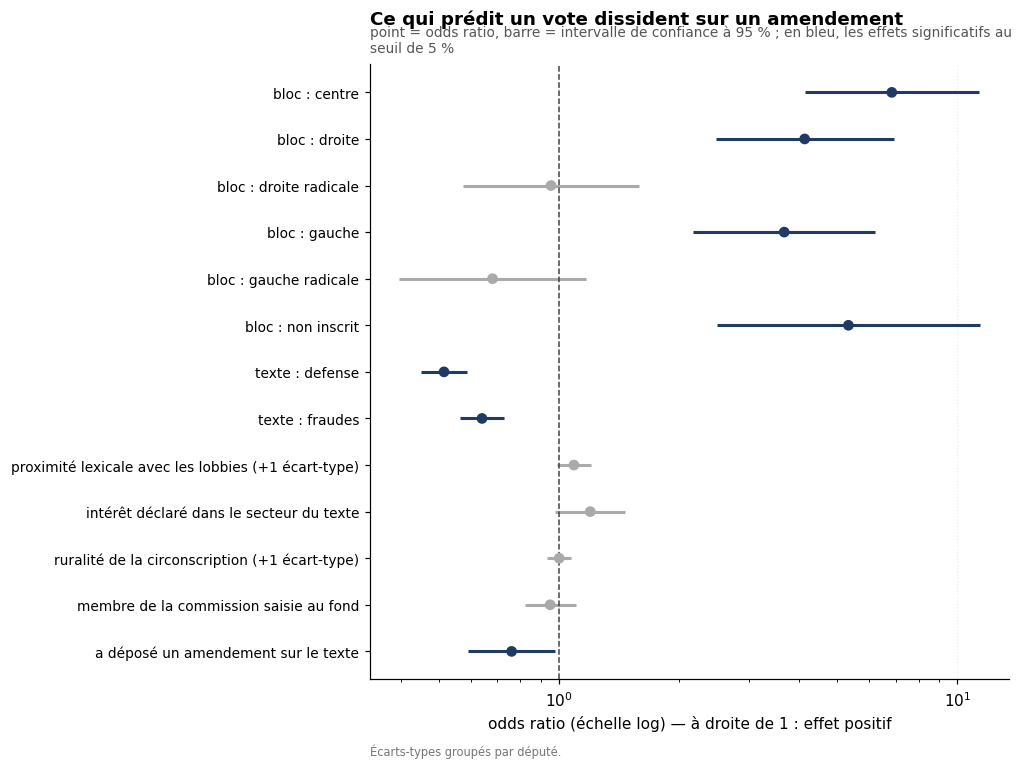

In [36]:
figure = viz.figure_coefficients(
    resultat["coefficients"], titre="Ce qui prédit un vote dissident sur un amendement")

**Lecture.** Un écart-type de proximité lexicale supplémentaire est associé à **+0,34 point**
de probabilité de dissidence, et un intérêt sectoriel déclaré à **+0,72 point**. Les deux
vont dans le sens attendu. **Aucun des deux n'est significatif au seuil de 5 %** (p ≈ 0,08).
*On ne conclut donc pas à un effet.*

Il faut aussi regarder l'ordre de grandeur : +0,34 point sur un taux de base de 4,3 %, soit
environ 8 % de hausse relative — petit devant l'effet du bloc politique (+5 à +8 points).

Le seul coefficient net est négatif : un député qui dépose des amendements sur un texte
dissident **moins** (−1,09 point). Déposer des amendements est plutôt un marqueur
d'investissement dans la ligne de son groupe.

### 6.2 Ce qui prédit l'adoption d'un amendement

Changement d'unité d'observation : l'amendement lui-même. On ne garde que ceux qui ont été
**tranchés** (adoptés ou rejetés) — un amendement retiré ou tombé n'a pas été jugé sur son
contenu.

In [37]:
adoption = models.modele_adoption(amendements)
print(f"n = {adoption['n']} amendements, {adoption['n_auteurs']} auteurs, "
      f"taux d'adoption {100 * adoption['taux_adoption']:.1f} %, "
      f"pseudo-R² = {adoption['pseudo_r2']:.3f}")
adoption["coefficients"][["coefficient", "erreur_standard", "p_value", "odds_ratio",
                          "significatif"]]

n = 1145 amendements, 159 auteurs, taux d'adoption 23.4 %, pseudo-R² = 0.192


,coefficient,erreur_standard,p_value,odds_ratio,significatif
Intercept,0.3197,0.3215,0.3200,1.3768,False
C(bloc)[T.droite],-1.0185,0.3694,0.0058,0.3611,True
C(bloc)[T.droite radicale],-2.6949,0.5951,0.0000,0.0676,True
C(bloc)[T.gauche],-1.5097,0.3877,0.0001,0.2210,True
C(bloc)[T.gauche radicale],-2.7330,0.5067,0.0000,0.0650,True
C(texte_cle)[T.defense],0.0298,0.3189,0.9257,1.0302,False
C(texte_cle)[T.fraudes],0.9111,0.2264,0.0001,2.4872,True
proximite_lobby_std,0.0116,0.0850,0.8910,1.0117,False
proximite_placebo_std,-0.2623,0.1080,0.0152,0.7693,True
dans_commission_competente,0.0933,0.2174,0.6677,1.0978,False


In [38]:
models.comparaison_placebo(adoption)

,mesure,coefficient,odds_ratio,ic_95,p_value,significatif_5pct
0,proximité aux lobbies du texte,0.0116,1.0117,[0.86 ; 1.20],0.8910,False
1,proximité aux lobbies d'un autre texte (témoin),-0.2623,0.7693,[0.62 ; 0.95],0.0152,True


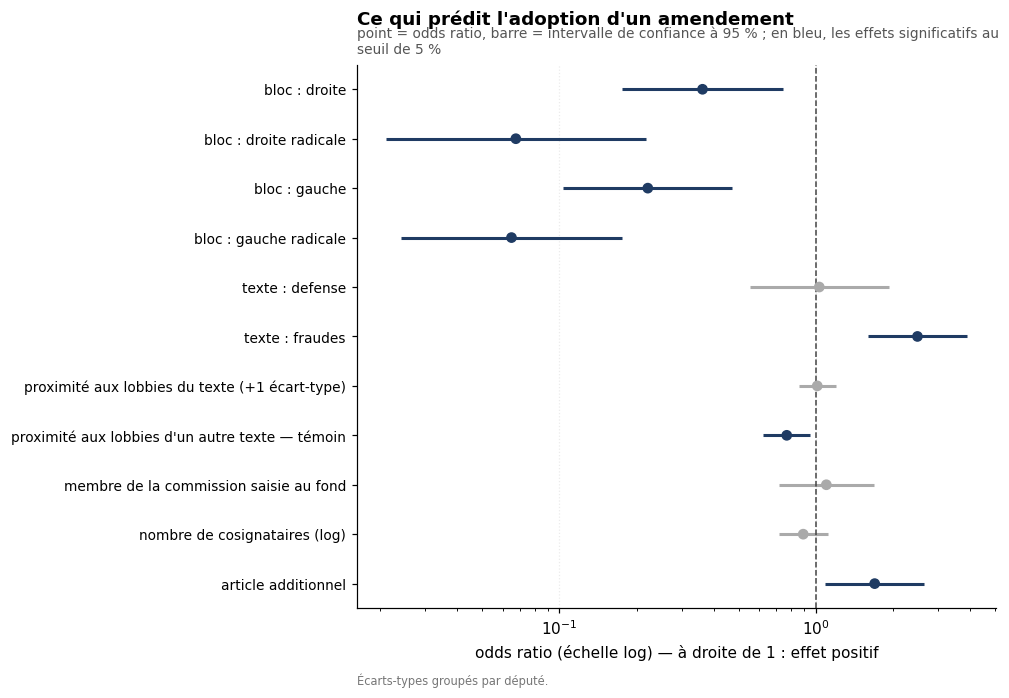

In [39]:
figure = viz.figure_coefficients(
    adoption["coefficients"], titre="Ce qui prédit l'adoption d'un amendement")

**Lecture, et c'est le résultat le plus intéressant du projet.** La proximité aux demandes
déclarées des lobbies du texte **n'a aucun effet** sur l'adoption (odds ratio 1,01,
p = 0,89). En revanche le **témoin** est significativement négatif (odds ratio 0,77,
p = 0,015) : un amendement dont le vocabulaire ressemble aux demandes d'un *autre* secteur
a moins de chances d'être adopté.

Sans le placebo, on aurait conclu « pas d'effet » et on serait passé à côté de ce que la
mesure capte réellement : elle sépare les amendements dans le sujet de ceux qui en sortent.
Un amendement hors sujet est rejeté — ce qui est rassurant sur le fonctionnement
parlementaire, et instructif sur ce que mesure un cosinus TF-IDF.

Ce qui prédit vraiment l'adoption reste l'appartenance politique : par rapport au centre,
les odds d'adoption sont divisés par 3 à droite et par 15 à la gauche radicale.

### 6.3 Qui écrit comme les lobbies ?

In [40]:
convergence = models.modele_convergence(table_finale)
print(f"n = {convergence['n']} députés-textes | pseudo-R² = {convergence['pseudo_r2']:.3f}")
convergence["coefficients"][["coefficient", "p_value", "odds_ratio", "significatif"]]

n = 166 députés-textes | pseudo-R² = 0.014


,coefficient,p_value,odds_ratio,significatif
Intercept,-0.1298,0.8159,0.8783,False
C(bloc)[T.droite],-0.1864,0.6987,0.8300,False
C(bloc)[T.droite radicale],-0.5242,0.2473,0.5920,False
C(bloc)[T.gauche],-0.0855,0.8473,0.9180,False
part_rurale_std,-0.0189,0.9105,0.9813,False
interet_sectoriel_declare,-0.5101,0.2582,0.6005,False
dans_commission_competente,0.1737,0.6229,1.1897,False
log_amendements,0.1449,0.4925,1.1559,False


Aucun coefficient significatif. Avec 166 observations, la puissance statistique est faible :
l'absence de résultat n'est pas un résultat d'absence.

### 6.4 Les intérêts déclarés des députés

Jusqu'ici, toutes les mesures d'exposition reposaient sur une inférence. Il existe pourtant
une information **déclarée par le député lui-même** et jamais inférée : ses intérêts privés.
Encore faut-il les nettoyer.

In [41]:
interets = charger("interets_classes")
brut = charger("hatvp_interets_deputes")
print(f"intérêts déclarés, bruts        : {len(brut):,}".replace(",", " "))
print(f"après dédoublonnage             : {len(interets):,}".replace(",", " "),
      f"({100 * (1 - len(interets) / len(brut)):.0f} % de doublons)")
print(f"rattachés à au moins un secteur : "
      f"{100 * interets['secteurs_interet'].ne('').mean():.0f} %")
interets["rubrique"].value_counts().rename("intérêts déclarés").to_frame()

intérêts déclarés  bruts        : 11 438
après dédoublonnage             : 5 556 (51 % de doublons)
rattachés à au moins un secteur : 34 %


,intérêts déclarés
rubrique,
participationDirigeant,2171
mandatElectif,1253
activProfCinqDerniere,959
participationFinanciere,786
fonctionBenevole,321
activConsultant,66


**51 % de doublons.** Un député qui dépose une déclaration initiale puis une modificative
voit ses intérêts inchangés recopiés à l'identique. Les compter deux fois aurait gonflé
mécaniquement les députés les plus actifs administrativement — exactement le contraire de ce
qu'on cherche à mesurer.

Le classement sectoriel repose sur un lexique court et lisible (`features.LEXIQUE_SECTEURS`).
Il ne rattache que **34 %** des libellés : « autoentrepreneur », « SCI familiale » ou
« consultant » ne disent rien du secteur. Ce taux est une limite, pas un détail.

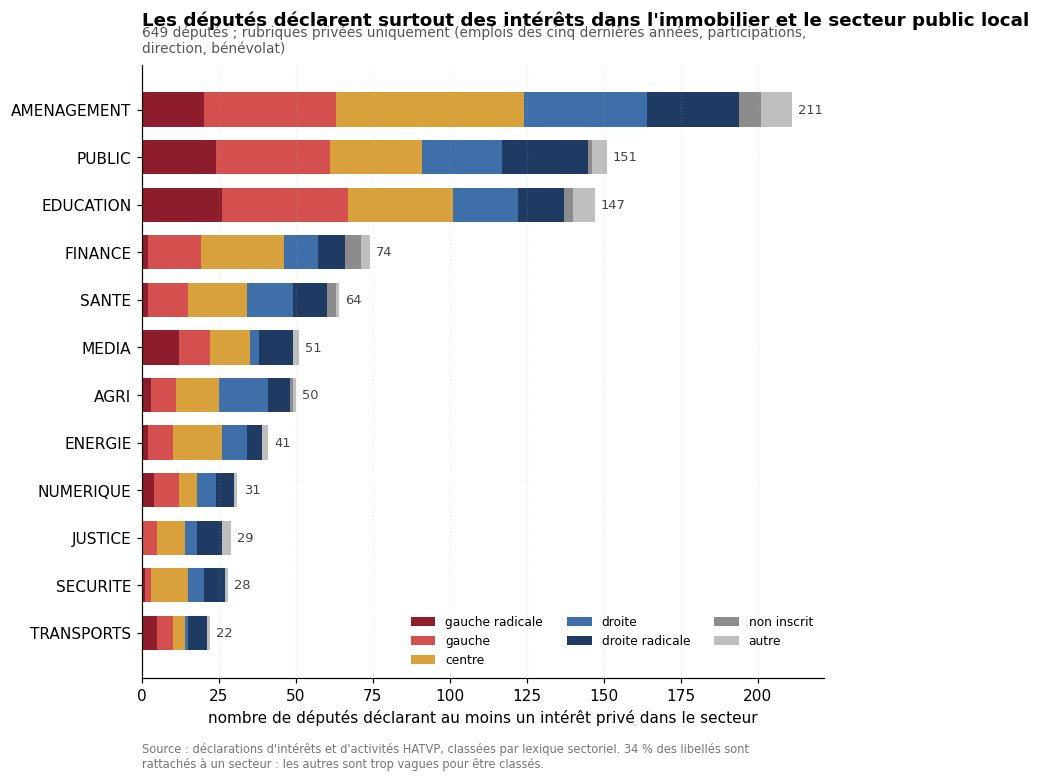

In [42]:
figure = viz.figure_secteurs_interets(charger("profil_sectoriel_deputes"))

In [43]:
specialisation = models.modele_specialisation(table_finale)
print(f"n = {specialisation['n']} députés-textes | "
      f"{100 * specialisation['part_amendeurs']:.0f} % ont déposé au moins un amendement | "
      f"pseudo-R² = {specialisation['pseudo_r2']:.3f}")
specialisation["coefficients"][["coefficient", "p_value", "odds_ratio", "significatif"]]

n = 1639 députés-textes | 13 % ont déposé au moins un amendement | pseudo-R² = 0.263


,coefficient,p_value,odds_ratio,significatif
Intercept,-3.2273,0.0000,0.0397,True
C(bloc)[T.centre],0.6881,0.2267,1.9899,False
C(bloc)[T.droite],1.0055,0.0846,2.7334,False
C(bloc)[T.droite radicale],0.8042,0.1525,2.2349,False
C(bloc)[T.gauche],1.1485,0.0451,3.1533,True
C(bloc)[T.gauche radicale],-0.3146,0.6153,0.7301,False
C(bloc)[T.non inscrit],0.4282,0.6458,1.5345,False
C(texte_cle)[T.defense],-0.6403,0.0018,0.5271,True
C(texte_cle)[T.fraudes],-1.0569,0.0000,0.3475,True
interet_sectoriel_declare,1.1011,0.0003,3.0075,True


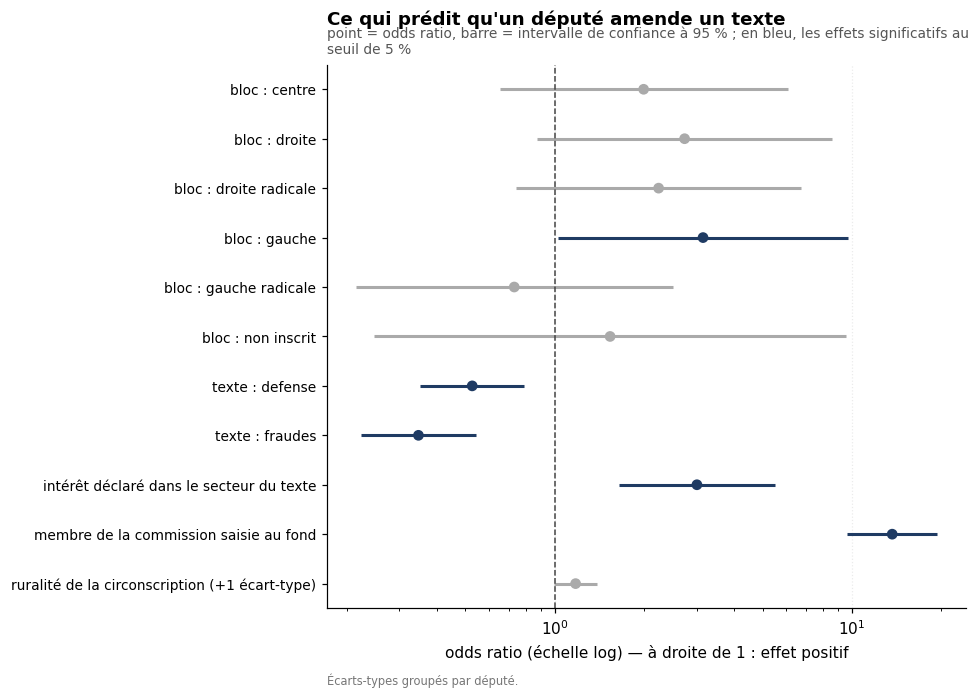

In [44]:
figure = viz.figure_coefficients(
    specialisation["coefficients"], titre="Ce qui prédit qu'un député amende un texte")

**Le résultat le mieux identifié du projet.** Un député qui déclare un intérêt privé dans le
secteur d'un texte a environ **trois fois plus de chances** d'y déposer un amendement
(odds ratio 3,0, p = 0,0003), et un membre de la commission saisie au fond environ
**quatorze fois plus**.

C'est la seule relation du projet qui n'exige **aucune inférence** : les intérêts sont
déclarés par le député lui-même, et le dépôt d'un amendement est un fait. Mais ce n'est pas
une mise en cause : un ancien agriculteur qui siège en commission des affaires économiques
et amende la loi agricole fait exactement ce pour quoi il a été élu. La frontière entre
**spécialisation** et **conflit d'intérêts** n'est pas dans ces données — elle est dans le
sens de l'amendement, que le TF-IDF ne voit pas.

## 7. Robustesse

Trois choix de ce projet n'ont aucune justification théorique et ont été faits à la main :
la largeur de la fenêtre temporelle, la façon de résumer la proximité lexicale, et la façon
de repérer un intérêt sectoriel. Un résultat qui dépend d'un de ces choix n'est pas un
résultat.

### 7.1 Déterminisme

Deux sources d'aléa existent dans le projet : le tirage de l'échantillon d'audit et le
sous-échantillonnage du corpus placebo. Les deux sont à graine fixe — encore faut-il le
vérifier, parce qu'une graine oubliée ne se voit jamais dans les résultats d'une seule
exécution.

In [45]:
pd.read_csv(config.PROCESSED / "determinisme.csv")

,calcul,empreinte_1,empreinte_2,identique
0,table_ciblage,1df87e2e041eb752,1df87e2e041eb752,True
1,echantillon_audit,2f55d866bb0f6461,2f55d866bb0f6461,True
2,table_amendements,d53ef02c35e6ffc3,d53ef02c35e6ffc3,True


### 7.2 Largeur de la fenêtre temporelle

In [46]:
sensibilite = pd.read_csv(config.PROCESSED / "sensibilite_fenetre.csv")
sensibilite.round(4)

,marge_mois,activites_niveau_1,organisations,n_votes,coef_proximite,p_proximite,pseudo_r2
0,0,184,63,87914,0.0646,0.1017,0.0765
1,3,187,64,87914,0.0691,0.1032,0.0765
2,6,208,80,87914,0.0861,0.0811,0.0765
3,12,209,80,87914,0.0861,0.0810,0.0765
4,24,256,99,87914,0.0809,0.1330,0.0764


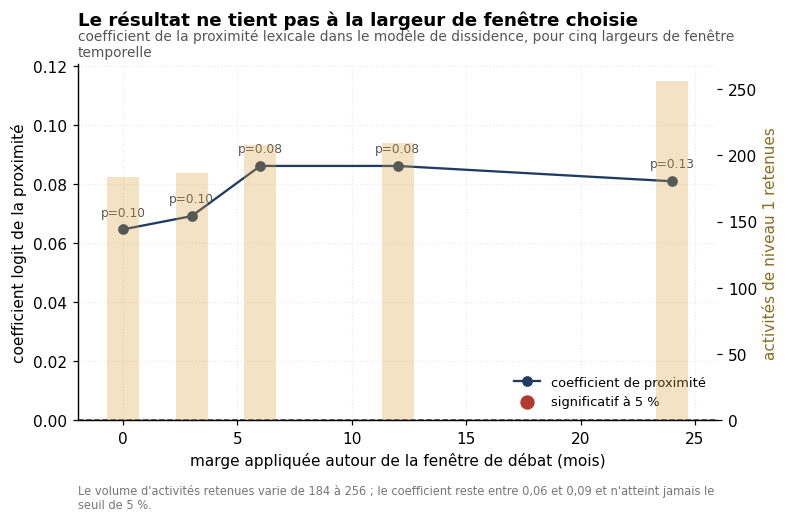

In [47]:
figure = viz.figure_sensibilite_fenetre(sensibilite)

Le volume d'activités retenues passe de 184 à 256 selon la fenêtre, mais le coefficient
reste entre 0,06 et 0,09 et **n'atteint jamais le seuil de 5 %**. Le non-résultat de la
section 6.1 n'est pas un artefact de ce choix.

### 7.3 Façon de résumer la proximité, et de repérer un intérêt

In [48]:
pd.read_csv(config.PROCESSED / "sensibilite_proximite.csv").round(4)

,mesure,n,coefficient,p_value,odds_ratio,pseudo_r2
0,proximite_max,87914,0.0861,0.0811,1.0899,0.0765
1,proximite_top5,87914,0.0668,0.2356,1.0691,0.0763


In [49]:
pd.read_csv(config.PROCESSED / "sensibilite_interet.csv").round(4)

,mesure,part_deputes_concernes,n,coefficient,odds_ratio,p_value
0,interet_sectoriel_declare,0.0472,1639,1.1011,3.0075,0.0003
1,interet_secteur_lexique,0.0879,1639,0.5304,1.6997,0.0541


In [50]:
concordance = robustesse.concordance_mesures_interet(table_finale)
print(concordance.to_string())
print(f"\naccord : {100 * concordance.attrs['accord']:.0f} %   "
      f"kappa de Cohen : {concordance.attrs['kappa']:.2f}")

repérage par classement sectoriel  False  True 
repérage par vocabulaire du texte              
False                               1521     94
True                                  25     55

accord : 93 %   kappa de Cohen : 0.45


**À lire avec attention, parce que ça tempère la section 6.4.** Les deux repérages de
l'intérêt sectoriel s'accordent à 93 % — mais sur une variable aussi rare, l'accord brut est
trompeur : le kappa de Cohen vaut **0,45**, soit un accord modéré. L'effet reste positif et
va dans le même sens avec les deux mesures, mais son ampleur passe d'un odds ratio de **3,0**
à **1,7**, et sa significativité de p = 0,0003 à p = 0,054.

La conclusion honnête est donc : *le sens de la relation est robuste, son ampleur ne l'est
pas.* Mieux vaut retenir le bas de la fourchette.

### 7.4 Robustesse du vote final : la deuxième lecture

In [51]:
lecture2 = charger("analyse_votes_finaux_lecture2")
pd.concat([
    models.pouvoir_predictif_bloc(table_finale).assign(lecture="1re"),
    models.pouvoir_predictif_bloc(lecture2).assign(lecture="2e"),
]).set_index("lecture", append=True)[
    ["n", "part_pour", "exactitude_regle_bloc", "nb_votes_atypiques"]]

,,n,part_pour,exactitude_regle_bloc,nb_votes_atypiques
texte_cle,lecture,,,,
agriculture,1re,547,0.6746,0.9945,3
defense,1re,562,0.7829,0.9342,37
fraudes,1re,557,0.6517,0.9946,3
agriculture,2e,520,0.5692,0.9327,35
defense,2e,488,0.7684,0.9242,37
fraudes,2e,517,0.6480,0.9826,9


Même conclusion aux deux lectures : la discipline de bloc explique de 93 à 99 % des votes.

## 8. Conclusion

**Ce qu'on trouve.**

1. Sur le **vote final**, il n'y a rien à expliquer : la discipline de groupe prédit 93 à
   99 % des votes. Toute recherche d'un effet du lobbying à ce niveau serait une illusion
   statistique.
2. Dans les **votes d'amendements**, où 4,3 % des positions s'écartent du groupe, la
   proximité lexicale avec les demandes déclarées des lobbies va dans le sens attendu mais
   **n'est pas significative** (p ≈ 0,08), et le reste pour toutes les largeurs de fenêtre
   testées.
3. Sur l'**adoption des amendements**, la proximité aux lobbies du texte n'a aucun effet ;
   c'est le **témoin** qui est significatif, et négatif. La mesure sépare les amendements
   dans le sujet de ceux qui en sortent, et les amendements hors sujet sont rejetés.
4. Le seul résultat **bien identifié** ne concerne pas les lobbies mais les députés
   eux-mêmes : un intérêt privé déclaré dans le secteur d'un texte multiplie par 1,7 à 3,0
   la probabilité d'y déposer un amendement. Spécialisation ou conflit d'intérêts ? Ces
   données ne tranchent pas.
5. Le lobbying déclaré est **très inégalement réparti** : 165 activités nomment le texte sur
   les fraudes, 29 la loi agricole, **aucune** le texte sur le logement, pourtant entouré de
   419 activités thématiquement proches.

**Ce qu'on ne peut pas dire.** Rien sur la causalité. Le répertoire ne nomme jamais le député
approché : ce qui est mesuré est une convergence de vocabulaire, compatible avec une
influence, avec un ciblage de députés déjà convaincus — la lecture la plus courante dans la
littérature — ou avec le jargon partagé d'un secteur. Et le registre est autodéclaratif : on
mesure le lobbying *déclaré*, sous-ensemble inconnu du lobbying réel, dont l'exhaustivité est
régulièrement contestée par Transparency International.

**Ce que le projet apporte vraiment.** Une chaîne reproductible qui rend quatre sources
officielles comparables, et surtout **une mesure du prix de ce rapprochement** : 99,5 % de
précision sur le rattachement interne à l'Assemblée après arbitrage temporel, 100 % sur
20 paires relues pour le ciblage HATVP strict, contre 6 % pour la règle thématique que nous
avions d'abord écrite. Le résultat méthodologique le plus solide est négatif : **une règle de
matching plausible peut être fausse neuf fois sur dix, et seule une relecture manuelle le
révèle.**

**Pistes.** Étendre aux textes budgétaires, où le lobbying déclaré est le plus dense ;
remplacer le TF-IDF par un modèle de phrases pour capter l'opposition sémantique que le
cosinus lexical ignore — un amendement qui *interdit* une substance et une demande de lobby
qui la *réautorise* se ressemblent beaucoup pour un cosinus ; et exploiter la direction des
amendements, qui est le vrai chaînon manquant entre spécialisation et capture.